In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [61]:
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LogisticRegression

from  sklearn.metrics import classification_report,confusion_matrix

In [15]:
df = pd.read_csv('candy-data.csv')

In [16]:
df.head(3)

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086


In [19]:
df = df.drop(columns=['competitorname'])

In [20]:
df.head(2)

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936


In [21]:
df.describe()

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,0.435294,0.447059,0.164706,0.164706,0.082353,0.082353,0.176471,0.247059,0.517647,0.478647,0.468882,50.316764
std,0.498738,0.500140,0.373116,0.373116,0.276533,0.276533,0.383482,0.433861,0.502654,0.282778,0.285740,14.714357
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011000,0.011000,22.445341
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.220000,0.255000,39.141056
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.465000,0.465000,47.829754
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.732000,0.651000,59.863998
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.988000,0.976000,84.180290


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   chocolate         85 non-null     int64  
 1   fruity            85 non-null     int64  
 2   caramel           85 non-null     int64  
 3   peanutyalmondy    85 non-null     int64  
 4   nougat            85 non-null     int64  
 5   crispedricewafer  85 non-null     int64  
 6   hard              85 non-null     int64  
 7   bar               85 non-null     int64  
 8   pluribus          85 non-null     int64  
 9   sugarpercent      85 non-null     float64
 10  pricepercent      85 non-null     float64
 11  winpercent        85 non-null     float64
dtypes: float64(3), int64(9)
memory usage: 8.1 KB


In [23]:
df.isnull().sum()

chocolate           0
fruity              0
caramel             0
peanutyalmondy      0
nougat              0
crispedricewafer    0
hard                0
bar                 0
pluribus            0
sugarpercent        0
pricepercent        0
winpercent          0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.head(2)

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936


In [26]:
y = df['chocolate']

In [35]:
y.shape

(85,)

In [29]:
# x = df.drop(columns=['choolate'])
x = df.drop(columns=['chocolate'])

In [30]:
x.shape,y.shape

((85, 11), (85,))

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [34]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((68, 11), (17, 11), (68,), (17,))

In [37]:
y_train = y_train.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

In [51]:
y_train.shape,y_test.shape

((68, 1), (17, 1))

In [53]:
# y_test.value_count()

In [54]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [55]:
y_pred = lr.predict(x_test)

In [68]:
# from sklearn import matrix
# confusion_matrix = metrics.confusion_matrix(y_test,y_pred)

In [69]:
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)

In [70]:
confusion_matrix

array([[8, 1],
       [1, 7]])

<Axes: >

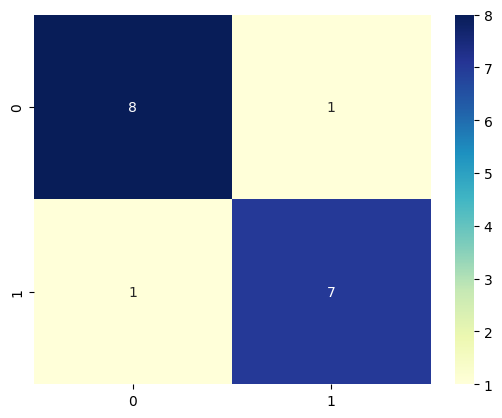

In [72]:
sns.heatmap(pd.DataFrame(confusion_matrix),annot=True,cmap="YlGnBu",fmt='g')

In [74]:
Accuracy = metrics.accuracy_score(y_test,y_pred)
Accuracy

0.8823529411764706

In [75]:
precision = metrics.precision_score(y_test,y_pred)
precision

0.875

In [76]:
recall = metrics.recall_score(y_test,y_pred)
recall

0.875

<Axes: >

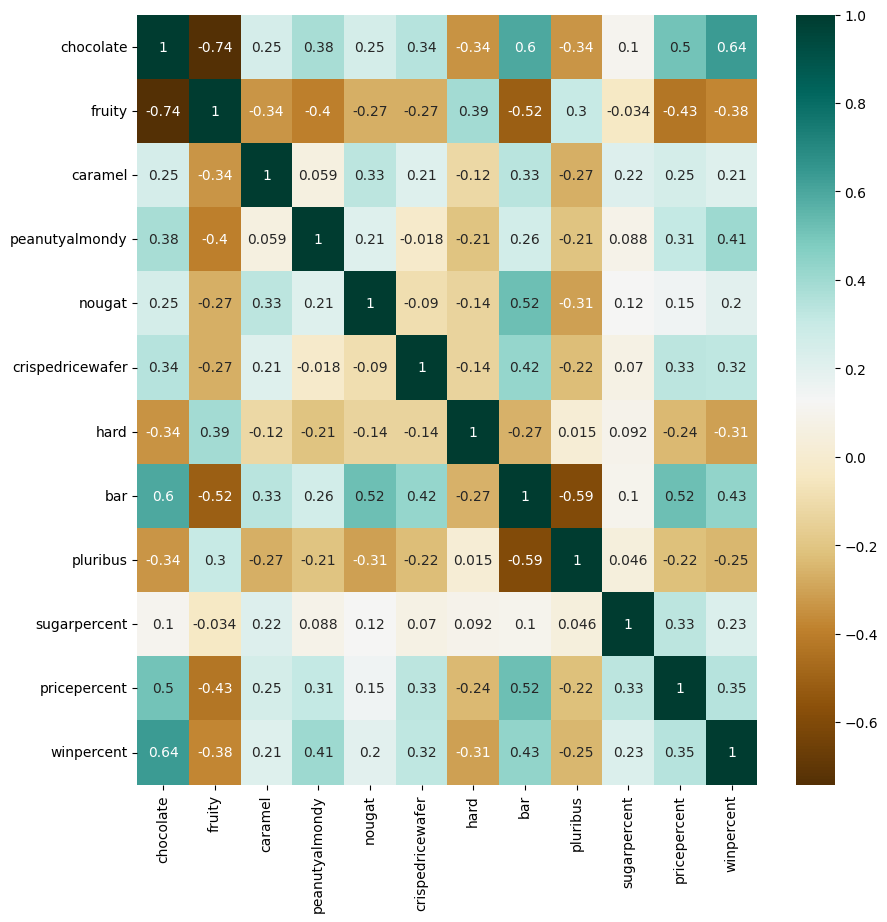

In [88]:
correlation_matrix=df.corr()
fig,ax = plt.subplots(figsize = (10,10))
sns.heatmap(correlation_matrix,ax=ax,cmap='BrBG',annot=True)
